In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder,OrdinalEncoder
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.linear_model import LassoCV,RidgeCV,LinearRegression,ElasticNetCV
from sklearn.pipeline import Pipeline

In [3]:
df_energy=pd.read_csv('../sources/turkey_electricity_consumption.csv')

In [4]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   object 
 6   avg_temperature_c           3072 non-null   float64
 7   humidity_pct                3063 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3067 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3078 non-null   float64
 13  num_subscribers             3078 

In [5]:
df_energy.head(5)

,city,region,city_type,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,...,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,monthly_consumption_gwh,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score
0,Kahramanmaras,Mediterranean,Medium City,2017,7,Summer,39.68,44.74,1178234,504.60,...,18.19,17.32,10:00,0.6645,"55,4",63.9 mm,₺2.01,"864,183",8.9,67%
1,Canakkale,Marmara,Small City,2016,6,Summer,NaN,50.92,542000,163.54,...,6.90,16.35,NaN,0.2411,"41,6",NaN,₺1.8,NaN,10.2,NaN
2,Izmir,Aegean,Megacity,2019,8,Summer,36.08,71.54,4394694,2722.83,...,8.73,27.60,18:00,3.7214,"66,9",225.0 mm,₺0.9,"434,525",9.3,NaN
3,Bursa,Marmara,Large City,2016,5,Spring,18.63,66.69,3056120,899.88,...,15.81,61.97,19:00,1.7494,"7,4",246.3 mm,₺1.82,"25,670",9.1,42%
4,Van,Eastern Anatolia,Medium City,2018,10,Autumn,7.07,65.44,1126384,255.37,...,5.37,19.47,08:00,0.4088,"65,6",28.7 mm,₺2.3,"5,011",7.2,84%


In [6]:
df_energy.describe()

,year,month,avg_temperature_c,humidity_pct,population,population_density_per_km2,gdp_per_capita_usd,industrial_zones_count,num_subscribers,renewable_energy_pct,grid_loss_pct,smart_meter_adoption_pct,monthly_consumption_gwh,avg_daily_sunshine_hours
count,3230.000000,3230.000000,3072.000000,3063.000000,3.230000e+03,3230.000000,3067.000000,3078.000000,3.078000e+03,3054.000000,3067.000000,3065.000000,3230.000000,3073.000000
mean,2019.000310,6.384830,17.185078,62.353369,2.118930e+06,1114.126161,12086.297483,5.972060,6.993987e+05,25.112508,12.438608,42.611980,1.366819,7.120631
std,2.565162,3.471365,11.674696,12.928196,2.790837e+06,2129.189935,3876.455639,7.284898,9.284067e+05,11.504863,4.347704,18.512508,2.207308,2.912210
min,2015.000000,1.000000,-11.100000,40.000000,5.420000e+05,111.660000,4012.870000,1.000000,1.531510e+05,5.010000,5.000000,10.010000,0.082200,2.000000
25%,2017.000000,3.000000,7.915000,51.225000,8.824560e+05,318.592500,9012.565000,3.000000,2.983238e+05,15.340000,8.655000,27.200000,0.448175,4.600000
50%,2019.000000,6.000000,17.785000,62.220000,1.264958e+06,552.110000,11129.880000,4.000000,4.251475e+05,24.920000,12.490000,42.670000,0.685750,7.200000
75%,2021.000000,9.000000,25.202500,73.415000,2.101263e+06,1028.460000,14757.260000,6.000000,6.886215e+05,35.005000,16.215000,58.160000,1.284225,9.600000
max,2023.000000,12.000000,44.860000,84.990000,1.584090e+07,28866.220000,22522.070000,42.000000,6.014709e+06,44.980000,19.980000,74.990000,27.620600,12.000000


In [7]:
df_energy.isnull().sum()

city                            0
region                          0
city_type                       0
year                            0
month                           0
season                          0
avg_temperature_c             158
humidity_pct                  167
population                      0
population_density_per_km2      0
gdp_per_capita_usd            163
industrialization_level         0
industrial_zones_count        152
num_subscribers               152
renewable_energy_pct          176
grid_loss_pct                 163
smart_meter_adoption_pct      165
peak_demand_hour              160
monthly_consumption_gwh         0
avg_wind_speed_kmh            157
monthly_rainfall_mm           137
electricity_price_tl_kwh      182
co2_emission_tons             180
avg_daily_sunshine_hours      157
infrastructure_score          166
dtype: int64

In [8]:
#df_energy['avg_temperature_c']=df_energy['avg_temperature_c'].fillna(df_energy.groupby(['city','season'])['avg_temperature_c'].transform('mean'))

In [9]:
df_energy.head(5)

,city,region,city_type,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,...,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,monthly_consumption_gwh,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score
0,Kahramanmaras,Mediterranean,Medium City,2017,7,Summer,39.68,44.74,1178234,504.60,...,18.19,17.32,10:00,0.6645,"55,4",63.9 mm,₺2.01,"864,183",8.9,67%
1,Canakkale,Marmara,Small City,2016,6,Summer,NaN,50.92,542000,163.54,...,6.90,16.35,NaN,0.2411,"41,6",NaN,₺1.8,NaN,10.2,NaN
2,Izmir,Aegean,Megacity,2019,8,Summer,36.08,71.54,4394694,2722.83,...,8.73,27.60,18:00,3.7214,"66,9",225.0 mm,₺0.9,"434,525",9.3,NaN
3,Bursa,Marmara,Large City,2016,5,Spring,18.63,66.69,3056120,899.88,...,15.81,61.97,19:00,1.7494,"7,4",246.3 mm,₺1.82,"25,670",9.1,42%
4,Van,Eastern Anatolia,Medium City,2018,10,Autumn,7.07,65.44,1126384,255.37,...,5.37,19.47,08:00,0.4088,"65,6",28.7 mm,₺2.3,"5,011",7.2,84%


In [10]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   object 
 6   avg_temperature_c           3072 non-null   float64
 7   humidity_pct                3063 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3067 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3078 non-null   float64
 13  num_subscribers             3078 

In [11]:
#df_energy['avg_temperature_c']=df_energy['avg_temperature_c'].fillna(df_energy.groupby(['city','season'])['avg_temperature_c'].transform('mean'))

In [12]:
groupby_columns=['city','season']

In [13]:
columns_to_fix=['avg_temperature_c','humidity_pct','gdp_per_capita_usd','industrial_zones_count',
                'num_subscribers',
                'renewable_energy_pct','renewable_energy_pct','grid_loss_pct',
                    'smart_meter_adoption_pct','avg_daily_sunshine_hours']

In [14]:
def colum_filler(columns,groups,df):
    for column in columns:
        df[column]=df[column].fillna(df.groupby(groups)[column].transform('mean')) 
    return df

In [15]:
for column in columns_to_fix:
    df_energy[column]=df_energy[column].fillna(df_energy.groupby(groupby_columns)[column].transform('mean'))

In [16]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   object 
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [17]:
df_energy.isnull().sum()

city                            0
region                          0
city_type                       0
year                            0
month                           0
season                          0
avg_temperature_c               0
humidity_pct                    0
population                      0
population_density_per_km2      0
gdp_per_capita_usd              0
industrialization_level         0
industrial_zones_count          0
num_subscribers                 0
renewable_energy_pct            0
grid_loss_pct                   0
smart_meter_adoption_pct        0
peak_demand_hour              160
monthly_consumption_gwh         0
avg_wind_speed_kmh            157
monthly_rainfall_mm           137
electricity_price_tl_kwh      182
co2_emission_tons             180
avg_daily_sunshine_hours        0
infrastructure_score          166
dtype: int64

In [18]:
df_energy['peak_demand_hour'].unique()

array(['10:00', nan, '18:00', '19:00', '08:00', '21:00', '20:00', '09:00'],
      dtype=object)

In [19]:
df_energy['peak_demand_hour'].isnull().sum()

np.int64(160)

In [20]:
hour_class = ['08:00', '09:00', '10:00', '18:00', '19:00', '20:00', '21:00', 'unknown']

In [21]:
ordinal_encoder=OrdinalEncoder(categories=[hour_class])

In [22]:
back_up=df_energy.copy()

In [23]:
df_energy['peak_demand_hour'] = df_energy['peak_demand_hour'].fillna('unknown')

In [24]:
df_energy['peak_demand_hour']=df_energy['peak_demand_hour'].astype('string')

In [25]:
df_energy['peak_demand_hour']=ordinal_encoder.fit_transform(df_energy[['peak_demand_hour']])

In [26]:
df_energy['peak_demand_hour']

0       2.0
1       7.0
2       3.0
3       4.0
4       0.0
       ... 
3225    3.0
3226    2.0
3227    5.0
3228    4.0
3229    2.0
Name: peak_demand_hour, Length: 3230, dtype: float64

In [27]:
df_energy['peak_demand_hour']=df_energy['peak_demand_hour'].astype(int)

In [28]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   object 
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [29]:
df_energy['avg_wind_speed_kmh'].unique()

array(['55,4', '41,6', '66,9', '7,4', '65,6', '47,4', '27,3', '8,5',
       '79,3', '5,5', '62,7', '61,0', '33,3', '42,1', '74,7', '34,7',
       '78,0', '44,3', '12,0', '66,0', '20,9', '46,6', '26,9', '66,2',
       '67,1', '21,6', '53,4', '12,1', nan, '35,9', '12,3', '15,8',
       '40,7', '10,8', '22,6', '72,4', '46,4', '17,6', '45,7', '8,1',
       '44,4', '53,0', '65,0', '67,6', '23,9', '77,6', '40,0', '24,8',
       '46,2', '20,3', '73,7', '75,4', '67,8', '37,5', '58,7', '68,9',
       '10,9', '35,7', '53,1', '78,2', '57,9', '52,7', '20,4', '27,0',
       '17,0', '27,8', '58,9', '76,8', '6,2', '28,4', '8,7', '70,6',
       '57,0', '67,0', '73,9', '16,5', '40,3', '46,0', '43,7', '59,0',
       '66,7', '12,9', '51,0', '23,3', '39,9', '56,8', '31,6', '12,8',
       '27,4', '17,2', '22,5', '45,8', '60,8', '53,6', '62,8', '64,3',
       '44,5', '24,2', '79,7', '13,0', '36,1', '16,6', '43,0', '65,5',
       '40,6', '37,6', '29,9', '59,3', '61,4', '51,1', '72,7', '15,0',
       '20,0', 

In [30]:
df_energy['monthly_rainfall_mm'].unique()

array(['63.9 mm', nan, '225.0 mm', ..., '79.7 mm', '27.4 mm', '250.1 mm'],
      dtype=object)

In [31]:
df_energy['monthly_rainfall_mm']=df_energy['monthly_rainfall_mm'].str.replace('mm','')

In [32]:
df_energy['monthly_rainfall_mm'].unique()

array(['63.9 ', nan, '225.0 ', ..., '79.7 ', '27.4 ', '250.1 '],
      dtype=object)

In [33]:
df_energy['monthly_rainfall_mm']=df_energy['monthly_rainfall_mm'].astype(float)

In [34]:
df_energy['monthly_rainfall_mm'].isnull().sum()

np.int64(137)

In [35]:
df_energy['avg_wind_speed_kmh']=df_energy['avg_wind_speed_kmh'].str.replace(',','.')

In [36]:
df_energy['avg_wind_speed_kmh']=df_energy['avg_wind_speed_kmh'].astype(float)

In [37]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   object 
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [38]:
seasons=df_energy['season'].unique()

In [39]:
seasons

array(['Summer', 'Spring', 'Autumn', 'Winter'], dtype=object)

In [40]:
ordinal_encoder2=OrdinalEncoder(categories=[seasons])

In [41]:
df_energy['season']=ordinal_encoder2.fit_transform(df_energy[['season']])

In [42]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [43]:
df_energy['electricity_price_tl_kwh']=back_up['electricity_price_tl_kwh'].str.replace('₺','')

In [44]:
df_energy['electricity_price_tl_kwh']=df_energy['electricity_price_tl_kwh'].astype(float)

In [45]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [46]:
df_energy['co2_emission_tons']=df_energy['co2_emission_tons'].str.replace(',','.')
df_energy['co2_emission_tons']=df_energy['co2_emission_tons'].astype(float)

In [47]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [48]:
df_energy['infrastructure_score'].unique()

array(['67%', nan, '42%', '84%', '35%', '69%', '64%', '70%', '76%', '62%',
       '95%', '86%', '72%', '54%', '52%', '58%', '39%', '65%', '36%',
       '51%', '88%', '78%', '41%', '77%', '45%', '68%', '99%', '30%',
       '90%', '85%', '47%', '81%', '87%', '43%', '89%', '63%', '80%',
       '40%', '44%', '53%', '96%', '59%', '92%', '46%', '82%', '38%',
       '55%', '34%', '73%', '56%', '74%', '97%', '32%', '79%', '98%',
       '61%', '93%', '49%', '83%', '94%', '60%', '31%', '66%', '37%',
       '57%', '48%', '71%', '33%', '50%', '75%', '91%'], dtype=object)

In [49]:
df_energy['infrastructure_score']=df_energy['infrastructure_score'].str.replace('%','')
df_energy['infrastructure_score']=df_energy['infrastructure_score'].fillna('0')
df_energy['infrastructure_score']=df_energy['infrastructure_score'].astype(int)

In [50]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [51]:
colums_to_fill=['avg_wind_speed_kmh','monthly_rainfall_mm','electricity_price_tl_kwh','co2_emission_tons']

In [52]:
colum_filler(colums_to_fill,groupby_columns,df_energy)

,city,region,city_type,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,...,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,monthly_consumption_gwh,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score
0,Kahramanmaras,Mediterranean,Medium City,2017,7,0.0,39.680000,44.74,1178234,504.60,...,18.19,17.32,2,0.6645,55.4,63.900000,2.01,864.183000,8.9,67
1,Canakkale,Marmara,Small City,2016,6,0.0,31.041304,50.92,542000,163.54,...,6.90,16.35,7,0.2411,41.6,163.827273,1.80,502.232545,10.2,0
2,Izmir,Aegean,Megacity,2019,8,0.0,36.080000,71.54,4394694,2722.83,...,8.73,27.60,3,3.7214,66.9,225.000000,0.90,434.525000,9.3,0
3,Bursa,Marmara,Large City,2016,5,1.0,18.630000,66.69,3056120,899.88,...,15.81,61.97,4,1.7494,7.4,246.300000,1.82,25.670000,9.1,42
4,Van,Eastern Anatolia,Medium City,2018,10,2.0,7.070000,65.44,1126384,255.37,...,5.37,19.47,0,0.4088,65.6,28.700000,2.30,5.011000,7.2,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3225,Samsun,Black Sea,Large City,2018,7,0.0,29.330000,84.37,1361505,774.93,...,13.35,35.51,3,0.6492,37.0,141.200000,1.47,360.394000,7.5,69
3226,Balıkesir,Marmara,Medium City,2023,11,2.0,13.850000,55.29,1264958,490.65,...,18.16,61.15,2,0.5840,67.5,75.800000,1.04,689.072000,10.9,50
3227,Erzurum,Eastern Anatolia,Medium City,2021,8,0.0,24.550000,72.28,762321,207.79,...,18.50,17.25,5,0.4445,73.2,183.200000,0.96,674.737000,2.2,45
3228,Denizli,Aegean,Medium City,2019,2,3.0,6.600000,40.51,1062840,650.13,...,19.14,48.20,4,0.7083,71.5,159.900000,2.19,698.580000,9.3,91


In [53]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [54]:
df_energy=colum_filler(colums_to_fill,groupby_columns,df_energy)

In [55]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        3230 non-null   object 
 1   region                      3230 non-null   object 
 2   city_type                   3230 non-null   object 
 3   year                        3230 non-null   int64  
 4   month                       3230 non-null   int64  
 5   season                      3230 non-null   float64
 6   avg_temperature_c           3230 non-null   float64
 7   humidity_pct                3230 non-null   float64
 8   population                  3230 non-null   int64  
 9   population_density_per_km2  3230 non-null   float64
 10  gdp_per_capita_usd          3230 non-null   float64
 11  industrialization_level     3230 non-null   object 
 12  industrial_zones_count      3230 non-null   float64
 13  num_subscribers             3230 

In [56]:
df_energy['target_monthly_consumption_gwh']=df_energy['monthly_consumption_gwh']

In [57]:
df_energy.drop('monthly_consumption_gwh',axis=1,inplace=True)

In [58]:
df_energy['industrialization_level'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [59]:
industrialization_level_encoded=['High','Medium','Low']

In [60]:
ordinal_encoder3=OrdinalEncoder(categories=[industrialization_level_encoded])


In [61]:
df_energy['industrialization_level']=ordinal_encoder3.fit_transform(df_energy[['industrialization_level']])

In [62]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            3230 non-null   object 
 1   region                          3230 non-null   object 
 2   city_type                       3230 non-null   object 
 3   year                            3230 non-null   int64  
 4   month                           3230 non-null   int64  
 5   season                          3230 non-null   float64
 6   avg_temperature_c               3230 non-null   float64
 7   humidity_pct                    3230 non-null   float64
 8   population                      3230 non-null   int64  
 9   population_density_per_km2      3230 non-null   float64
 10  gdp_per_capita_usd              3230 non-null   float64
 11  industrialization_level         3230 non-null   float64
 12  industrial_zones_count          32

In [63]:
df_energy['city'].tolist

<bound method IndexOpsMixin.tolist of 0       Kahramanmaras
1           Canakkale
2               Izmir
3               Bursa
4                 Van
            ...      
3225           Samsun
3226        Balıkesir
3227          Erzurum
3228          Denizli
3229          Erzurum
Name: city, Length: 3230, dtype: object>

In [64]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            3230 non-null   object 
 1   region                          3230 non-null   object 
 2   city_type                       3230 non-null   object 
 3   year                            3230 non-null   int64  
 4   month                           3230 non-null   int64  
 5   season                          3230 non-null   float64
 6   avg_temperature_c               3230 non-null   float64
 7   humidity_pct                    3230 non-null   float64
 8   population                      3230 non-null   int64  
 9   population_density_per_km2      3230 non-null   float64
 10  gdp_per_capita_usd              3230 non-null   float64
 11  industrialization_level         3230 non-null   float64
 12  industrial_zones_count          32

In [65]:
df_energy_data=df_energy.drop(['city','region','city_type'],axis=1)

In [66]:
df_energy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   year                            3230 non-null   int64  
 1   month                           3230 non-null   int64  
 2   season                          3230 non-null   float64
 3   avg_temperature_c               3230 non-null   float64
 4   humidity_pct                    3230 non-null   float64
 5   population                      3230 non-null   int64  
 6   population_density_per_km2      3230 non-null   float64
 7   gdp_per_capita_usd              3230 non-null   float64
 8   industrialization_level         3230 non-null   float64
 9   industrial_zones_count          3230 non-null   float64
 10  num_subscribers                 3230 non-null   float64
 11  renewable_energy_pct            3230 non-null   float64
 12  grid_loss_pct                   32

In [67]:
df_energy_data.corr()

,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,gdp_per_capita_usd,industrialization_level,industrial_zones_count,...,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score,target_monthly_consumption_gwh
year,1.000000,0.012994,0.002610,-0.013253,0.001376,-0.006418,0.000406,0.013078,-0.019392,-0.007013,...,0.019915,-0.003469,0.009356,-0.002586,0.013999,-0.011153,0.020540,0.018156,-0.002207,0.021267
month,0.012994,1.000000,-0.028554,0.157817,-0.003964,-0.004148,-0.005205,0.001611,0.008025,-0.006898,...,-0.004924,-0.005235,0.009881,0.012834,0.001227,0.002353,-0.012833,0.016955,0.018930,-0.014163
season,0.002610,-0.028554,1.000000,-0.885937,0.009953,0.003790,0.000355,0.043257,-0.032128,0.004821,...,0.033570,-0.028915,-0.012896,0.001704,0.006109,-0.005470,-0.008256,0.022632,-0.003209,0.028953
avg_temperature_c,-0.013253,0.157817,-0.885937,1.000000,-0.025448,0.002814,0.003131,-0.011208,-0.001014,0.004936,...,-0.033173,0.029229,0.003238,0.006548,0.002318,0.008887,0.016684,-0.002218,0.006012,-0.024679
humidity_pct,0.001376,-0.003964,0.009953,-0.025448,1.000000,-0.016481,-0.020432,-0.033008,0.024391,-0.017684,...,0.029957,0.004102,0.021760,-0.005997,-0.008884,-0.036999,0.003057,-0.003572,0.019656,-0.009027
population,-0.006418,-0.004148,0.003790,0.002814,-0.016481,1.000000,0.737931,0.492287,-0.521747,0.991774,...,-0.009847,0.009906,-0.005272,-0.001294,0.000723,0.001700,-0.003884,0.003818,0.013113,0.958042
population_density_per_km2,0.000406,-0.005205,0.000355,0.003131,-0.020432,0.737931,1.000000,0.355189,-0.373403,0.731089,...,0.019379,0.004305,0.021258,-0.012913,0.012791,0.000510,0.007706,0.004465,0.031696,0.702803
gdp_per_capita_usd,0.013078,0.001611,0.043257,-0.011208,-0.033008,0.492287,0.355189,1.000000,-0.923367,0.519127,...,-0.008660,0.003563,0.006392,0.013508,-0.004794,-0.015273,0.012512,0.005837,-0.007653,0.509099
industrialization_level,-0.019392,0.008025,-0.032128,-0.001014,0.024391,-0.521747,-0.373403,-0.923367,1.000000,-0.548827,...,0.005653,-0.007338,-0.002014,-0.015465,0.002372,0.023984,-0.015061,-0.012474,-0.001286,-0.539052
industrial_zones_count,-0.007013,-0.006898,0.004821,0.004936,-0.017684,0.991774,0.731089,0.519127,-0.548827,1.000000,...,-0.008976,0.011845,-0.003231,0.000411,0.003346,0.000469,-0.001720,0.003638,0.009740,0.952270


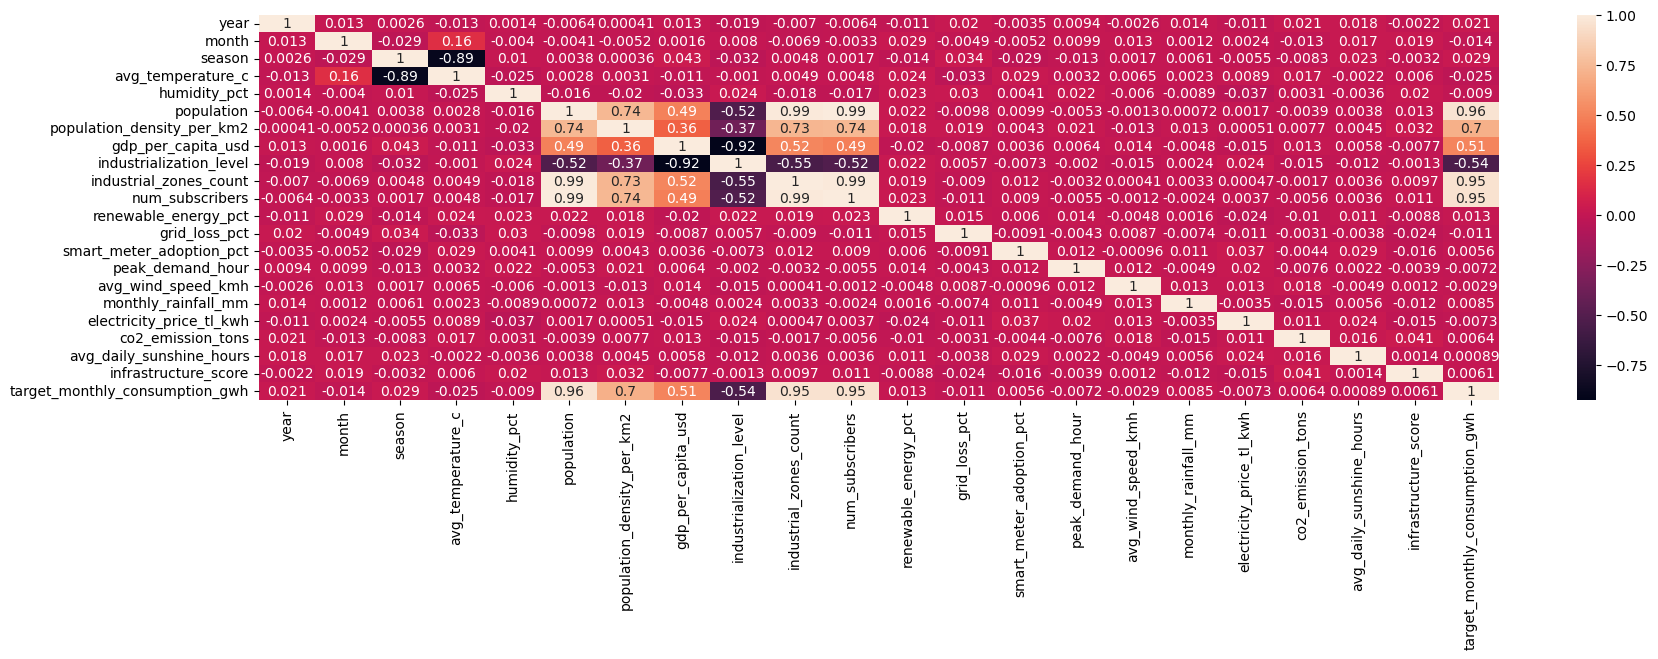

In [68]:
plt.figure(figsize=(20,5))
sns.heatmap(df_energy_data.corr(),annot=True)
plt.show()

In [69]:
#independent & dependet: 
X=df_energy_data.drop('target_monthly_consumption_gwh',axis=1)
y=df_energy_data['target_monthly_consumption_gwh']

In [70]:
X

,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,gdp_per_capita_usd,industrialization_level,industrial_zones_count,...,renewable_energy_pct,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score
0,2017,7,0.0,39.680000,44.74,1178234,504.60,10827.290000,2.0,3.0,...,19.52,18.19,17.32,2,55.4,63.900000,2.01,864.183000,8.9,67
1,2016,6,0.0,31.041304,50.92,542000,163.54,9837.840000,2.0,3.0,...,9.68,6.90,16.35,7,41.6,163.827273,1.80,502.232545,10.2,0
2,2019,8,0.0,36.080000,71.54,4394694,2722.83,18538.770000,0.0,11.0,...,5.55,8.73,27.60,3,66.9,225.000000,0.90,434.525000,9.3,0
3,2016,5,1.0,18.630000,66.69,3056120,899.88,20256.280000,0.0,8.0,...,16.81,15.81,61.97,4,7.4,246.300000,1.82,25.670000,9.1,42
4,2018,10,2.0,7.070000,65.44,1126384,255.37,10634.070000,2.0,4.0,...,13.62,5.37,19.47,0,65.6,28.700000,2.30,5.011000,7.2,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3225,2018,7,0.0,29.330000,84.37,1361505,774.93,12796.870000,2.0,4.0,...,10.70,13.35,35.51,3,37.0,141.200000,1.47,360.394000,7.5,69
3226,2023,11,2.0,13.850000,55.29,1264958,490.65,10307.550000,2.0,5.0,...,14.73,18.16,61.15,2,67.5,75.800000,1.04,689.072000,10.9,50
3227,2021,8,0.0,24.550000,72.28,762321,207.79,9486.410000,2.0,3.0,...,42.62,18.50,17.25,5,73.2,183.200000,0.96,674.737000,2.2,45
3228,2019,2,3.0,6.600000,40.51,1062840,650.13,13093.022857,1.0,4.0,...,20.04,19.14,48.20,4,71.5,159.900000,2.19,698.580000,9.3,91


In [71]:
y

0       0.6645
1       0.2411
2       3.7214
3       1.7494
4       0.4088
         ...  
3225    0.6492
3226    0.5840
3227    0.4445
3228    0.7083
3229    0.2665
Name: target_monthly_consumption_gwh, Length: 3230, dtype: float64

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [73]:
X_train.shape

(2422, 21)

In [74]:
y_train.shape

(2422,)

In [75]:
X_train.corr()

,year,month,season,avg_temperature_c,humidity_pct,population,population_density_per_km2,gdp_per_capita_usd,industrialization_level,industrial_zones_count,...,renewable_energy_pct,grid_loss_pct,smart_meter_adoption_pct,peak_demand_hour,avg_wind_speed_kmh,monthly_rainfall_mm,electricity_price_tl_kwh,co2_emission_tons,avg_daily_sunshine_hours,infrastructure_score
year,1.000000,0.011337,0.002775,-0.012702,-0.004572,-0.004445,-0.005524,0.015528,-0.024804,-0.005061,...,-0.028185,0.009645,0.006770,0.008263,-0.015158,0.006409,-0.000239,0.005431,0.031345,0.006279
month,0.011337,1.000000,-0.031776,0.162428,-0.011165,0.006342,0.010821,0.026089,-0.013472,0.003641,...,0.020476,-0.012838,0.005397,0.008904,0.007686,0.011528,0.005196,-0.011761,0.019506,0.013193
season,0.002775,-0.031776,1.000000,-0.885583,0.005505,0.010915,0.009786,0.074492,-0.057179,0.014526,...,-0.010400,0.036829,-0.025461,-0.000645,-0.000575,0.005921,0.004771,-0.002966,0.028944,-0.000283
avg_temperature_c,-0.012702,0.162428,-0.885583,1.000000,-0.016026,0.000780,0.001915,-0.031367,0.013004,0.000601,...,0.025803,-0.042745,0.027186,-0.010181,0.001615,0.004553,0.000793,0.018506,-0.011849,-0.005165
humidity_pct,-0.004572,-0.011165,0.005505,-0.016026,1.000000,-0.032040,-0.037821,-0.043624,0.041315,-0.030626,...,0.017628,0.051893,-0.001708,0.046597,-0.011889,-0.018505,-0.026010,0.016803,0.006054,0.028923
population,-0.004445,0.006342,0.010915,0.000780,-0.032040,1.000000,0.746421,0.498373,-0.525660,0.992120,...,0.033794,-0.013664,0.008022,-0.017571,0.005604,0.001304,-0.005701,0.002407,0.009204,0.024278
population_density_per_km2,-0.005524,0.010821,0.009786,0.001915,-0.037821,0.746421,1.000000,0.378627,-0.394023,0.739676,...,0.031301,0.010425,0.017216,-0.005650,-0.010735,0.028115,-0.001915,0.010759,0.018650,0.035517
gdp_per_capita_usd,0.015528,0.026089,0.074492,-0.031367,-0.043624,0.498373,0.378627,1.000000,-0.919456,0.522677,...,-0.000533,-0.004946,-0.022263,0.021703,0.019277,-0.003196,-0.023551,0.005980,0.002576,-0.006430
industrialization_level,-0.024804,-0.013472,-0.057179,0.013004,0.041315,-0.525660,-0.394023,-0.919456,1.000000,-0.550493,...,-0.001494,0.005317,0.020489,-0.017403,-0.019063,0.005222,0.034870,-0.006995,-0.008742,-0.002627
industrial_zones_count,-0.005061,0.003641,0.014526,0.000601,-0.030626,0.992120,0.739676,0.522677,-0.550493,1.000000,...,0.033003,-0.010449,0.009781,-0.014398,0.006276,0.006440,-0.006092,0.003004,0.008299,0.016955


In [76]:
def correlation_for_drop(df,threshold):
    corr=df.corr()
    columns_to_drop=set()
    for i in range (len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j])>threshold:
                 columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [77]:
corr_to_drop=correlation_for_drop(X_train,0.8)

In [78]:
X_train.drop(corr_to_drop,axis=1,inplace=True)
X_test.drop(corr_to_drop,axis=1,inplace=True)

In [79]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2422 entries, 2165 to 2693
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        2422 non-null   int64  
 1   month                       2422 non-null   int64  
 2   season                      2422 non-null   float64
 3   humidity_pct                2422 non-null   float64
 4   population                  2422 non-null   int64  
 5   population_density_per_km2  2422 non-null   float64
 6   gdp_per_capita_usd          2422 non-null   float64
 7   renewable_energy_pct        2422 non-null   float64
 8   grid_loss_pct               2422 non-null   float64
 9   smart_meter_adoption_pct    2422 non-null   float64
 10  peak_demand_hour            2422 non-null   int64  
 11  avg_wind_speed_kmh          2422 non-null   float64
 12  monthly_rainfall_mm         2422 non-null   float64
 13  electricity_price_tl_kwh    2422 no

In [80]:
scaler=StandardScaler()

In [81]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [82]:
regression=LinearRegression()

In [83]:
line_reg=regression.fit(X_train_scaled,y_train)

In [84]:
line_reg

LinearRegression()

In [85]:
y_pred=regression.predict(X_test_scaled)

mean absolute error: 0.2695787830777332 mean squared error: 0.2877048206842148 r2 score: 0.9270667244745678


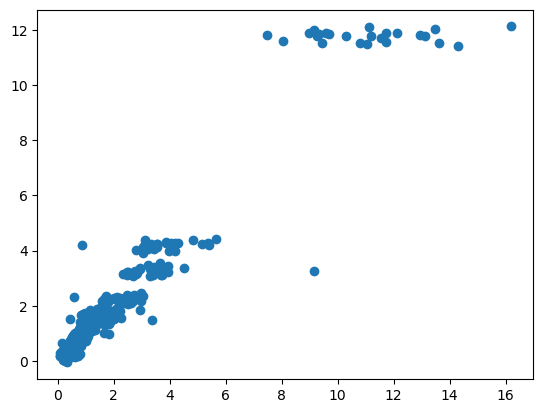

In [94]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('mean absolute error:',mae,'mean squared error:',mse,'r2 score:',r2)
plt.scatter(y_test,y_pred)
plt.show()

In [87]:
y_test

1073    2.9912
247     0.4452
1914    0.6239
2234    0.4137
2102    0.6010
         ...  
1082    1.9155
2184    0.6496
1596    1.7343
1504    3.7301
1067    2.0398
Name: target_monthly_consumption_gwh, Length: 808, dtype: float64

mean absolute error: 0.26333228758419247 mean squared error: 0.28427064432705634 r2 score: 0.9279372894163158


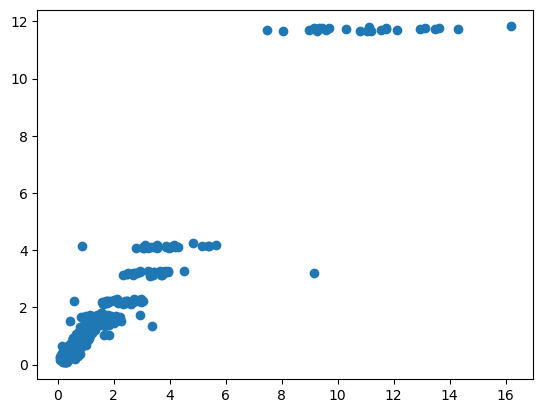

In [95]:
lasso=LassoCV(cv=5)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)
lasso_mean_sq=mean_squared_error(y_test,y_pred_lasso)
lasso_abs=mean_absolute_error(y_test,y_pred_lasso)
lasso_r2=r2_score(y_test,y_pred_lasso)
print('mean absolute error:',lasso_abs,'mean squared error:',lasso_mean_sq,'r2 score:',lasso_r2)
plt.scatter(y_test,y_pred_lasso)
plt.show()

mean absolute error: 0.26852094822980827 mean squared error: 0.2842981671056793 r2 score: 0.9279303123820355


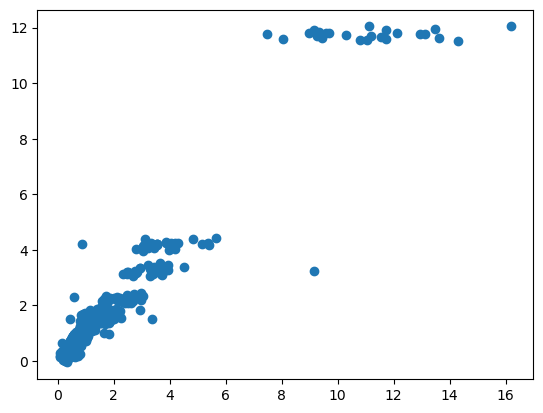

In [101]:
ridge=RidgeCV(cv=5)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)
ridge_mean_sq=mean_squared_error(y_test,y_pred_ridge)
ridge_abs=mean_absolute_error(y_test,y_pred_ridge)
ridge_r2=r2_score(y_test,y_pred_ridge)
print('mean absolute error:',ridge_abs,'mean squared error:',ridge_mean_sq,'r2 score:',ridge_r2)
plt.scatter(y_test,y_pred_ridge)
plt.show()

mean absolute error: 0.2629134541885341 mean squared error: 0.2795905525052471 r2 score: 0.929123694376485


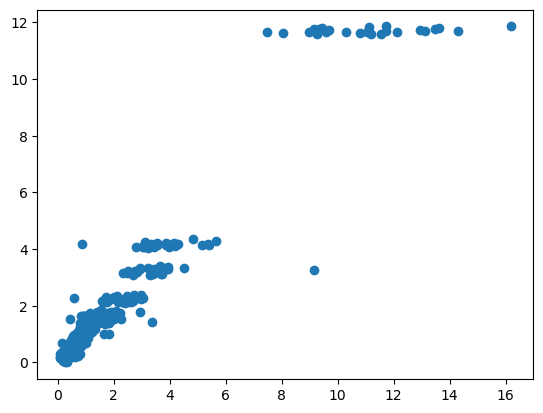

In [100]:
elastic=ElasticNetCV(cv=5)
elastic.fit(X_train_scaled,y_train)
y_pred_elastic=elastic.predict(X_test_scaled)
elastic_mean_sq=mean_squared_error(y_test,y_pred_elastic)
elastic_abs=mean_absolute_error(y_test,y_pred_elastic)
elastic_r2=r2_score(y_test,y_pred_elastic)
print('mean absolute error:',elastic_abs,'mean squared error:',elastic_mean_sq,'r2 score:',elastic_r2)
plt.scatter(y_test,y_pred_elastic)
plt.show()